## TMW - Nahom Gebreyohannis, Niranjana Parashar

In [1]:
import numpy as np
import pandas as pd
import scipy as sp
import matplotlib.pyplot as plt

In [2]:
#general data
mz = 40.9e-3 #+- 0.5g [pulling mass]
m = 308.7e-3 #+- 0.2g [mass on rod]

Angle-Time-Law and Torque

In [3]:
#measurement 1 (variating torque)
rm = 18.75e-2 #+- 0.2mm [radius mass distance]
ds1 = 173.1e-2 #+- 0.2mm [diameter string]
n1 = np.array([0, 1, 2, 3])
tabel1 = pd.DataFrame([[0, 3.8, 5.24, 6.41],
                       [0, 2.68, 4.57, 5.78],
                       [0, 3.72, 5.22, 6.61],
                       [0, 3.12, 4.72, 5.96],
                       [0, 3.48, 5.21, 6.42],
                       [0, 3.69, 5.21, 6.38],
                       [0, 3.35, 4.94, 6.14],
                       [0, 3.36, 4.88, 6.14],
                       [0, 3.43, 5.11, 6.35],
                       [0, 3.21, 4.21, 6.05]],
                      columns=['$n=0$', '$n=1$', '$n=2$', '$n=3$'],
                      index=['meas 1', 'meas 2', 'meas 3', 'meas 4', 'meas 5', 'meas 6', 'meas 7', 'meas 8', 'meas 9', 'meas 10'])
tabel1.index.name = '$t$ in s'
tabel1.loc['average <t>'] = list(np.around(tabel1.mean(axis=0).to_numpy(), 2))

t1_av = tabel1.mean(axis=0).to_numpy()

tabel1

,$n=0$,$n=1$,$n=2$,$n=3$
$t$ in s,,,,
meas 1,0.0,3.80,5.24,6.41
meas 2,0.0,2.68,4.57,5.78
meas 3,0.0,3.72,5.22,6.61
meas 4,0.0,3.12,4.72,5.96
meas 5,0.0,3.48,5.21,6.42
meas 6,0.0,3.69,5.21,6.38
meas 7,0.0,3.35,4.94,6.14
meas 8,0.0,3.36,4.88,6.14
meas 9,0.0,3.43,5.11,6.35


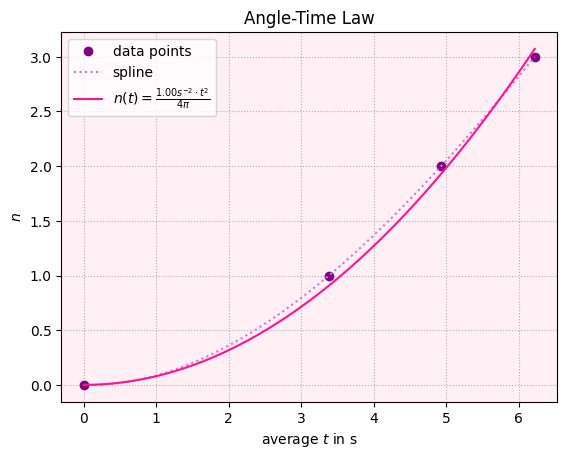

In [4]:
t1 = np.linspace(min(t1_av), max(t1_av))

#real data:
plt.plot(t1_av, n1, 'o', label='data points', color='purple')

#spline interpolation of data:
n1opt = sp.interpolate.CubicSpline(t1_av, n1)
n1plt = n1opt(t1) 
plt.plot(t1, n1plt, ':', label='spline', color='orchid')

#theoretical curve fit for data:
def ntfunc(t1, a1):
    return a1*(t1**2)/(4*np.pi)
#a1 = n1*4*np.pi/(t1_av**2)  #alternative to a1plt without curve fit func, bc only 1 parameter
popt, pcov = sp.optimize.curve_fit(ntfunc, t1_av, n1)
a1plt = popt
n1plt_cf = ntfunc(t1, a1plt)
labelf1 = rf'$n(t) = \frac{{{a1plt[0]:.2f}s^{{-2}} \cdot t^2}}{{4 \pi}}$'
plt.plot(t1, n1plt_cf, label=labelf1, color='deeppink')

#plot enviornment:
plt.grid(ls='dotted')
plt.xlabel('average $t$ in s')
plt.ylabel('$n$')
plt.title('Angle-Time Law')
plt.legend()
ax = plt.gca()
ax.set_facecolor("lavenderblush")
plt.show()

In [5]:
#measurement 2 (variating torque)
rm =  18.75e-2 #+- 0.2mm [radius mass distance]
ds2 = 112.6e-2 #+- 0.2mm [diameter string]
n2 = np.array([0, 1, 2, 3, 4])
tabel2 = pd.DataFrame([[0, 4.19, 6.05, 7.57, 8.94],
                       [0, 4.22, 6.20, 7.58, 8.97],
                       [0, 4.38, 6.37, 7.81, 9.00],
                       [0, 4.54, 6.43, 7.89, 9.44],
                       [0, 4.53, 6.43, 7.90, 9.20],
                       [0, 4.38, 6.40, 7.89, 9.21],
                       [0, 4.55, 6.44, 7.94, 9.31],
                       [0, 4.25, 6.22, 7.79, 9.07],
                       [0, 4.55, 6.45, 7.94, 9.28],
                       [0, 4.64, 6.48, 8.01, 9.31]],
                     columns=['$n=0$', '$n=1$', '$n=2$', '$n=3$', '$n=4$'],
                     index=['meas 1', 'meas 2', 'meas 3', 'meas 4', 'meas 5', 'meas 6', 'meas 7', 'meas 8', 'meas 9', 'meas 10'])
tabel2.index.name = '$t$ in s'
tabel2.loc['average <t>'] = list(np.around(tabel2.mean(axis=0).to_numpy(), 2))

t2_av = tabel2.mean(axis=0).to_numpy()

tabel2

,$n=0$,$n=1$,$n=2$,$n=3$,$n=4$
$t$ in s,,,,,
meas 1,0.0,4.19,6.05,7.57,8.94
meas 2,0.0,4.22,6.20,7.58,8.97
meas 3,0.0,4.38,6.37,7.81,9.00
meas 4,0.0,4.54,6.43,7.89,9.44
meas 5,0.0,4.53,6.43,7.90,9.20
meas 6,0.0,4.38,6.40,7.89,9.21
meas 7,0.0,4.55,6.44,7.94,9.31
meas 8,0.0,4.25,6.22,7.79,9.07
meas 9,0.0,4.55,6.45,7.94,9.28


In [6]:
#measurement 3 (variating torque)
rm =  18.75e-2 #+- 0.2mm [radius mass distance]
ds3 = 52.7e-2 #+- 0.2mm [diameter string]
n2 = np.array([1, 2, 3, 4])
tabel3 = pd.DataFrame([[0, 6.34, 9.24, 11.30, 13.25],
                       [0, 6.26, 8.84, 11.26, 13.11],
                       [0, 6.44, 9.20, 11.50, 13.35],
                       [0, 6.61, 9.38, 11.67, 13.52],
                       [0, 6.38, 9.10, 11.28, 13.14],
                       [0, 6.22, 8.98, 11.11, 12.99],
                       [0, 6.33, 8.99, 11.14, 13.03],
                       [0, 6.28, 9.04, 11.24, 13.03],
                       [0, 6.22, 8.93, 11.09, 13.02],
                       [0, 6.24, 9.04, 11.16, 13.09]],
                     columns=['$n=0$', '$n=1$', '$n=2$', '$n=3$', '$n=4$'],
                     index=['meas 1', 'meas 2', 'meas 3', 'meas 4', 'meas 5', 'meas 6', 'meas 7', 'meas 8', 'meas 9', 'meas 10'])
tabel3.index.name = '$t$ in s'
tabel3.loc['average <t>'] = list(np.around(tabel3.mean(axis=0).to_numpy(), 2))

t3_av = tabel3.mean(axis=0).to_numpy()

tabel3

,$n=0$,$n=1$,$n=2$,$n=3$,$n=4$
$t$ in s,,,,,
meas 1,0.0,6.34,9.24,11.30,13.25
meas 2,0.0,6.26,8.84,11.26,13.11
meas 3,0.0,6.44,9.20,11.50,13.35
meas 4,0.0,6.61,9.38,11.67,13.52
meas 5,0.0,6.38,9.10,11.28,13.14
meas 6,0.0,6.22,8.98,11.11,12.99
meas 7,0.0,6.33,8.99,11.14,13.03
meas 8,0.0,6.28,9.04,11.24,13.03
meas 9,0.0,6.22,8.93,11.09,13.02


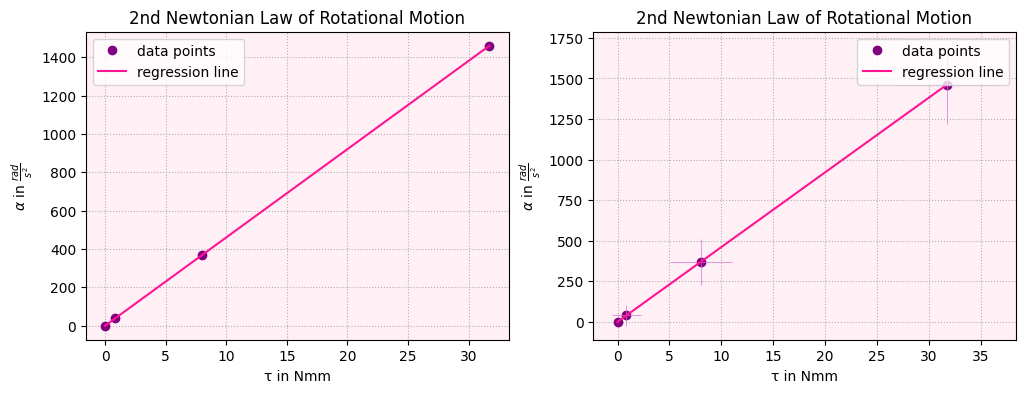

In [7]:
at1_1 = (ds1*np.pi*2)/((t1_av[1])**2)
at1_2 = (ds1*np.pi*2*2)/((t1_av[2])**2)
at1_3 = (ds1*np.pi*2*3)/((t1_av[3])**2)
at1 = (at1_1+at1_2+at1_3)/3 #translational acceleration mean [meas 1]
at2_1 = (ds2*np.pi*2)/((t2_av[1])**2)
at2_2 = (ds2*np.pi*2*2)/((t2_av[2])**2)
at2_3 = (ds2*np.pi*2*3)/((t2_av[3])**2)
at2_4 = (ds2*np.pi*2*4)/((t2_av[4])**2)
at2 = (at2_1+at2_2+at2_3+at2_4)/4 #translational acceleration mean [meas 2]
at3_1 = (ds3*np.pi*2)/((t3_av[1])**2)
at3_2 = (ds3*np.pi*2*2)/((t3_av[2])**2)
at3_3 = (ds3*np.pi*2*3)/((t3_av[3])**2)
at3_4 = (ds3*np.pi*2*4)/((t3_av[4])**2)
at3 = (at3_1+at3_2+at3_3+at3_4)/4 #translational acceleration mean [meas 3]

T1 = mz*at1*ds1/2
T2 = mz*at2*ds2/2
T3 = mz*at3*ds3/2
T = np.array([0, T1, T2, T3])
T = T*1e3
α = T/(2*m*rm**2)

#plot 1
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)

#real data:
plt.plot(T, α, 'o', label='data points', color='purple')

#regression line:
linr = sp.stats.linregress(T, α)
T_lr = np.linspace(min(T), max(T), 101)
α_lr = linr.slope*T_lr+linr.intercept
plt.plot(T_lr, α_lr, label='regression line', color='deeppink')

#plot enviornment:
plt.grid(ls='dotted')
plt.xlabel('τ in Nmm')
plt.ylabel('$\\alpha$ in $\\frac{rad}{s^2}$')
plt.title('2nd Newtonian Law of Rotational Motion')
plt.legend()
ax = plt.gca()
ax.set_facecolor("lavenderblush")


#plot 2
plt.subplot(1,2,2)

#real data:
plt.plot(T, α, 'o', label='data points', color='purple')

#uncertainty:
at1_1_max = ((ds1+0.2e-3)*np.pi*2)/(((t1_av[1]- 0.2))**2)
uc_at = at1_1_max - at1_1
T1_max = (mz+0.5e-3)*(at1+uc_at)*(ds1+0.2e-3)/2
T2_max = (mz+0.5e-3)*(at2+uc_at)*(ds2+0.2e-3)/2
T3_max = (mz+0.5e-3)*(at3+uc_at)*(ds3+0.2e-3)/2
T_max = np.array([0, T1_max, T2_max, T3_max])
T_max = T_max*1e3 
T_uc = T_max - T
α_uc = (T_max/(2*(m-0.2e-3)*(rm-0.1e-2)**2)) - α
plt.errorbar(T, α, xerr=T_uc, yerr=α_uc, fmt='none', ecolor='orchid', elinewidth=0.5)

#regression line:
linr = sp.stats.linregress(T, α)
T_lr = np.linspace(min(T), max(T), 101)
α_lr = linr.slope*T_lr+linr.intercept
plt.plot(T_lr, α_lr, label='regression line', color='deeppink')

#plot enviornment:
plt.grid(ls='dotted')
plt.xlabel('τ in Nmm')
plt.ylabel('$\\alpha$ in $\\frac{rad}{s^2}$')
plt.title('2nd Newtonian Law of Rotational Motion')
plt.legend()
ax = plt.gca()
ax.set_facecolor("lavenderblush")
plt.show()

Inertia 

In [8]:
#measurement A (variating inertia)   # = measurement 2 
rm_a =  18.75 #+- 0.2mm [radius mass distance]
ds = 112.6 #+- 0.2mm [diameter string]
n = np.array([1, 2, 3, 4])
tabelA = pd.DataFrame([[0, 4.19, 6.05, 7.57, 8.94],
                       [0, 4.22, 6.20, 7.58, 8.97],
                       [0, 4.38, 6.37, 7.81, 9.00],
                       [0, 4.54, 6.43, 7.89, 9.44],
                       [0, 4.53, 6.43, 7.90, 9.20],
                       [0, 4.38, 6.40, 7.89, 9.21],
                       [0, 4.55, 6.44, 7.94, 9.31],
                       [0, 4.25, 6.22, 7.79, 9.07],
                       [0, 4.55, 6.45, 7.94, 9.28],
                       [0, 4.64, 6.48, 8.01, 9.31]],
                     columns=['$n=0$', '$n=1$', '$n=2$', '$n=3$', '$n=4$'],
                     index=['meas 1', 'meas 2', 'meas 3', 'meas 4', 'meas 5', 'meas 6', 'meas 7', 'meas 8', 'meas 9', 'meas 10'])
tabelA.index.name = '$t$ in s'
tabelA.loc['average <t>'] = list(np.around(tabelA.mean(axis=0).to_numpy(), 2))

tA_av = tabelA.mean(axis=0).to_numpy()

tabelA

,$n=0$,$n=1$,$n=2$,$n=3$,$n=4$
$t$ in s,,,,,
meas 1,0.0,4.19,6.05,7.57,8.94
meas 2,0.0,4.22,6.20,7.58,8.97
meas 3,0.0,4.38,6.37,7.81,9.00
meas 4,0.0,4.54,6.43,7.89,9.44
meas 5,0.0,4.53,6.43,7.90,9.20
meas 6,0.0,4.38,6.40,7.89,9.21
meas 7,0.0,4.55,6.44,7.94,9.31
meas 8,0.0,4.25,6.22,7.79,9.07
meas 9,0.0,4.55,6.45,7.94,9.28


In [9]:
#measurement B (variating inertia)
dm_b = 548 #mm [diameter mass distance]
rm_b = dm_b/2  #+- 0.2mm [radius mass distance]
ds = 112.6 #+- 0.2mm [diameter string]
n = np.array([1, 2, 3, 4])
tabelB = pd.DataFrame([[0, 5.53, 8.12, 10.00, 11.67],
                       [0, 5.68, 8.07, 9.97, 11.56],
                       [0, 5.58, 8.04, 10.02, 11.70],
                       [0, 5.65, 8.12, 10.15, 11.85],
                       [0, 5.69, 8.21, 10.18, 11.75],
                       [0, 5.38, 7.87, 9.73, 11.42],
                       [0, 5.43, 7.90, 9.90, 11.52],
                       [0, 5.54, 8.09, 10.07, 11.64],
                       [0, 5.28, 7.72, 9.58, 11.33],
                       [0, 5.34, 7.68, 9.71, 11.31]],
                     columns=['$n=0$', '$n=1$', '$n=2$', '$n=3$', '$n=4$'],
                     index=['meas 1', 'meas 2', 'meas 3', 'meas 4', 'meas 5', 'meas 6', 'meas 7', 'meas 8', 'meas 9', 'meas 10'])
tabelB.index.name = '$t$ in s'
tabelB.loc['average <t>'] = list(np.around(tabelB.mean(axis=0).to_numpy(), 2))

tB_av = tabelB.mean(axis=0).to_numpy()

tabelB

,$n=0$,$n=1$,$n=2$,$n=3$,$n=4$
$t$ in s,,,,,
meas 1,0.0,5.53,8.12,10.00,11.67
meas 2,0.0,5.68,8.07,9.97,11.56
meas 3,0.0,5.58,8.04,10.02,11.70
meas 4,0.0,5.65,8.12,10.15,11.85
meas 5,0.0,5.69,8.21,10.18,11.75
meas 6,0.0,5.38,7.87,9.73,11.42
meas 7,0.0,5.43,7.90,9.90,11.52
meas 8,0.0,5.54,8.09,10.07,11.64
meas 9,0.0,5.28,7.72,9.58,11.33


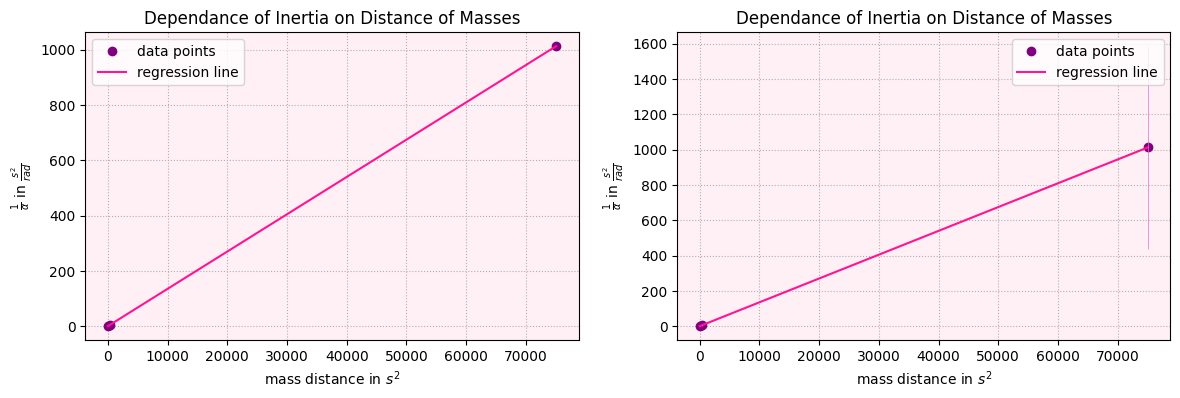

In [ ]:
r_sqrd = (np.array([0, rm_a, rm_b]))**2
A1_α = (2*mz*r_sqrd) / ((ds/2)*m*at2) 

#plot 1
plt.figure(figsize=(14,4))
plt.subplot(1,2,1)

#real data:
plt.plot(r_sqrd, A1_α, 'o', label='data points', color='purple')

#regression line:
linr = sp.stats.linregress(r_sqrd, A1_α)
r_lr = np.linspace(min(r_sqrd), max(r_sqrd), 101)
α2_lr = linr.slope*r_lr+linr.intercept
plt.plot(r_lr, α2_lr, label='regression line', color='deeppink')

#plot enviornment:
plt.grid(ls='dotted')
plt.xlabel('mass distance in $s^2$')
plt.ylabel('$\\frac{1}{\\alpha}$ in $\\frac{s^2}{rad}$')
plt.title('Dependance of Inertia on Distance of Masses')
plt.legend()
ax = plt.gca()
ax.set_facecolor("lavenderblush")


#plot 2
plt.subplot(1,2,2)

#real data:
plt.plot(r_sqrd, A1_α, 'o', label='data points', color='purple')

#regression line:
linr = sp.stats.linregress(r_sqrd, A1_α)
r_lr = np.linspace(min(r_sqrd), max(r_sqrd), 101)
α2_lr = linr.slope*r_lr+linr.intercept
plt.plot(r_lr, α2_lr, label='regression line', color='deeppink')

#uncertainty:
r_sqrd_uc = np.array([0, 0.2**2, 0.2**2])
A1_α_uc = (2*(mz+0.5e-3)*(r_sqrd+0.2**2)) /(((ds-0.2e-3)/2)*(m-0.2e-3)*(at2-uc_at)) - A1_α 
plt.errorbar(r_sqrd, A1_α, xerr=r_sqrd_uc, yerr=A1_α_uc, fmt='none', ecolor='orchid', elinewidth=0.5)

#plot enviornment:
plt.grid(ls='dotted')
plt.xlabel('mass distance in $s^2$')
plt.ylabel('$\\frac{1}{\\alpha}$ in $\\frac{s^2}{rad}$')
plt.title('Dependance of Inertia on Distance of Masses')
plt.legend()
ax = plt.gca()
ax.set_facecolor("lavenderblush")
plt.show() 